# Úkol č. 2 - Využití neuronových sítí

  * **Deadline je 13. 5. 2024, 23:59:59**, pokud odevzdáte úkol do 20. 5. 2024, 23:59:59, budete penalizování -12 body, pozdější odevzdání je bez bodu.
  * V rámci tohoto úkolu musíte sestrojit vhodný model neuronové sítě pro vícetřídou klasifikaci.
  * Část bodů získáte za správné vypracování a část bodů získáte za výslednou přesnost Vašeho modelu na evaluačních datech.
    
> **Úkoly jsou zadány tak, aby Vám daly prostor pro invenci. Vymyslet _jak přesně_ budete úkol řešit, je důležitou součástí zadání a originalita či nápaditost bude také hodnocena!**

Využívejte buňky typu `Markdown` k vysvětlování Vašeho postupu. Za nepřehlednost budou strhávány body.

## Zdroj dat

 * Zdrojem dat jsou soubory `train.csv` a `evaluate.csv`.
 * Jedná se o obrázky 32x32 pixelů ve stupních šedi, které byly nějakým způsobem vyrobeny z [Fashion Mnist datasetu](https://www.kaggle.com/datasets/zalando-research/fashionmnist).
 * Soubor `train.csv` obsahuje trénovací data.
 * Cílová (vysvětlovaná) proměnná se jmenuje **label**.
 * Soubor `evaluate.csv` obsahuje testovací data bez hodnot skutečných labelů.

## Pokyny k vypracování (max 18 bodů)

**Body zadání**, za jejichž (poctivé) vypracování získáte **18 bodů**:
  * V notebooku načtěte data ze souboru `train.csv`. Vhodným způsobem si je rozdělte na podmnožiny, které Vám poslouží pro trénování, porovnávání modelů a následnou predikci výkonnosti finálního modelu.
  * Proveďte základní průzkum dat a svá pozorování diskutujte. Některé obrázky také zobrazte.
  * Sestrojte a natrénujte několik variant modelu dopředné neuronové sítě. Přitom v rámci výpočetních možností:
      * Okomentujte vhodnost daného modelu pro daný typ úlohy.
      * Experimentujte s různými hloubkami a velikosmi vrstev.
      * Experimentujte se standardizací/normalizací dat.
      * Experimentujte s různými optimalizačními metodami.
      * Experimentujte s různými regularizačními technikami.
      * Získané výsledky vždy řádně okomentujte.

  * Sestrojte model konvoluční neuronové sítě. Přitom v rámci výpočetních možností:
      * Okomentujte vhodnost daného modelu pro daný typ úlohy.
      * Experimentujte s různými hloubkami a velikosmi vrstev.
      * Experimentujte se standardizací/normalizací dat.
      * Experimentujte s různými optimalizačními metodami.
      * Experimentujte s různými regularizačními technikami.
      * Získané výsledky vždy řádně okomentujte.
    
  * Ze všech zkoušených možností vyberte finální model a odhadněte, jakou přesnost můžete očekávat na nových datech, která jste doposud neměli k dispozici.
  
  * Nakonec načtěte vyhodnocovací data ze souboru`evaluate.csv`. Pomocí finálního modelu napočítejte predikce pro tyto data (vysvětlovaná proměnná v nich již není). Vytvořte soubor `results.csv`, ve kterém získané predikce uložíte do sloupce **label** a identifikátory do sloupce **ID**. Tento soubor též odevzdejte (uložte do projektu vedle notebooku).
   
   * Ukázka prvních řádků souboru `results.csv`:
  
```
ID,label
0,0
1,1
...
```

## Vyhodnocovací část (max 7 bodů)
Za přesnost (accuraccy) na odevzdaných predikcích pro vyhodnocovací množnu získáte dalších max **7 bodů**.

Označíme-li $A$ přesnost, které jste dosáhli, zaokrouhlenou na 2 desetinná místa, akumulují se výsledné body podle následujících pravidel:
* pokud $A \geq 0.80$ obdržíte +1 bod
* pokud $A \geq 0.83$ obdržíte +1 bod
* pokud $A \geq 0.86$ obdržíte +1 bod
* pokud $A \geq 0.87$ obdržíte +1 bod
* pokud $A \geq 0.88$ obdržíte +1 bod
* pokud $A \geq 0.89$ obdržíte +1 bod
* pokud $A \geq 0.90$ obdržíte +1 bod

**Příklad:** Pokud bude Vaše přesnost 0.856, vyjde A = 0.86 a vy získáte 3 body.


## Poznámky k odevzdání

  * Řiďte se pokyny ze stránky https://courses.fit.cvut.cz/BI-ML2/homeworks/index.html.
  * Vytvořte i csv soubor `results.csv` s predikcemi a uložte ho v rámci projektu vedle ipython notebooku.

In [1]:
import math
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
import torch.optim as optim
import torchvision
from torchvision import datasets, transforms
from torch.utils.data import TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import ParameterGrid

In [2]:
df = pd.read_csv("train.csv")

In [3]:
df.shape

(52500, 1025)

In [4]:
df["label"].unique()

array([3, 7, 9, 5, 1, 6, 0, 4, 8, 2])

In [5]:
Xdata = df.drop("label", axis = 1)
Ydata = df["label"]
rd_seed = 300
Xtrain, Xtest, Ytrain, Ytest = train_test_split(Xdata, Ydata, test_size=0.4, random_state=rd_seed) 
Xval, Xtest, Yval, Ytest = train_test_split(Xtest, Ytest, test_size=0.5, random_state=rd_seed)

In [6]:
def show_pic(index):
    image_pixels = df.iloc[index, 1:].values.astype(np.uint8)
    image = image_pixels.reshape((32, 32))

    tmp = Ydata.iloc[index]
    print(tmp)
    
    plt.imshow(image, cmap='gray')
    plt.title('Fashion MNIST Image')
    plt.axis('off')
    plt.show()

4


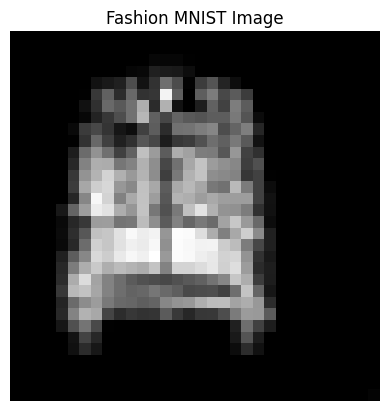

0


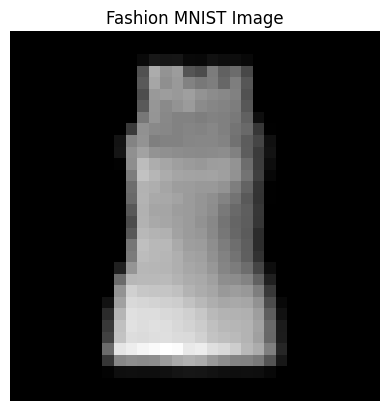

7


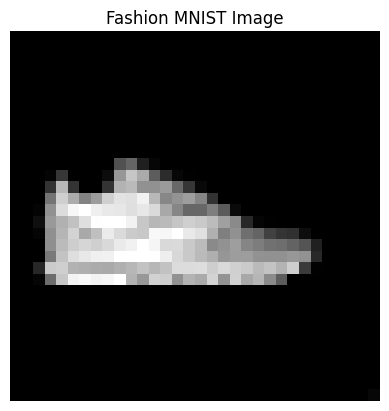

0


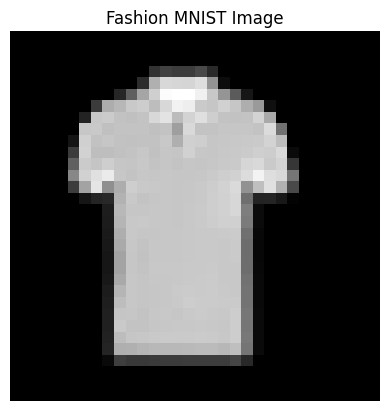

4


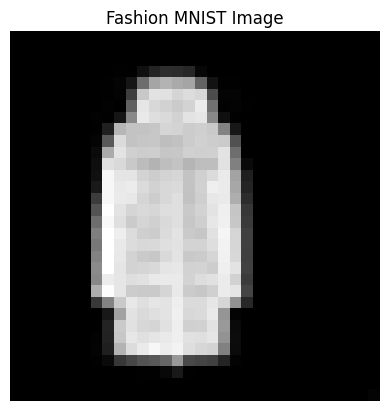

0


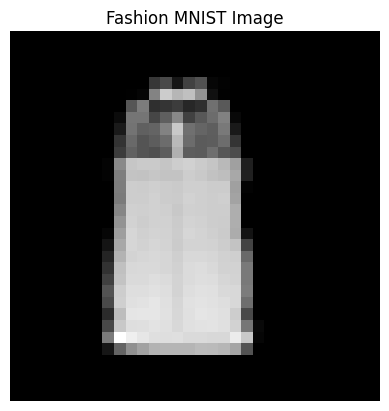

5


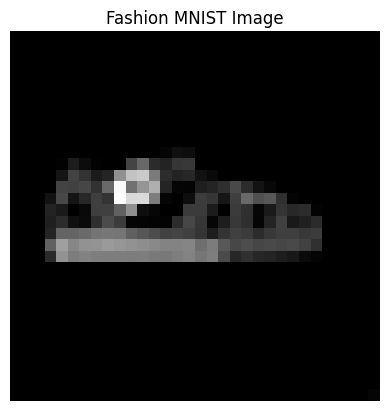

0


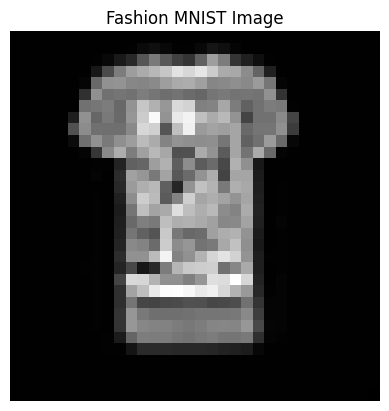

In [7]:
show_pic(50000)
show_pic(10)
show_pic(12654)
show_pic(165)
show_pic(15674)
show_pic(123)
show_pic(48612)
show_pic(3245)

In [8]:
std_scaler = StandardScaler()
std_scaler.fit(Xtrain)

mm_scaler = MinMaxScaler()
mm_scaler.fit(Xtrain)

Xtrain_np = Xtrain
Xval_np = Xval
Xtest_np = Xtest
Ytrain_np = Ytrain
Yval_np = Yval
Ytest_np = Ytest

In [9]:
Xtrain_std = std_scaler.transform(Xtrain)
Xval_std = std_scaler.transform(Xval)
Xtest_std = std_scaler.transform(Xtest)

Xtrain_mm = mm_scaler.transform(Xtrain)
Xval_mm = mm_scaler.transform(Xval)
Xtest_mm = mm_scaler.transform(Xtest)



In [10]:
Xtrain = torch.tensor(Xtrain.values, dtype=torch.float32)
Xtrain_std = torch.tensor(Xtrain_std, dtype=torch.float32)
Xtrain_mm = torch.tensor(Xtrain_mm, dtype=torch.float32)
Ytrain = torch.tensor(Ytrain.values, dtype=torch.long)

Xval = torch.tensor(Xval.values, dtype=torch.float32)
Xval_std = torch.tensor(Xval_std, dtype=torch.float32)
Xval_mm = torch.tensor(Xval_mm, dtype=torch.float32)
Yval = torch.tensor(Yval.values, dtype=torch.long)

Xtest = torch.tensor(Xtest.values, dtype=torch.float32)
Xtest_std = torch.tensor(Xtest_std, dtype=torch.float32)
Xtest_mm = torch.tensor(Xtest_mm, dtype=torch.float32)
Ytest = torch.tensor(Ytest.values, dtype=torch.long)

In [11]:
type(Xtrain_std)

torch.Tensor

In [12]:
Xtrain.shape

torch.Size([31500, 1024])

In [13]:
type(Xtrain)

torch.Tensor

### Dopředná neuronová síť

In [30]:
dropout_prob = 0.5
l2_lambda=0.01

class Net(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, num_layers, regularization):
        super(Net, self).__init__()
        self.input_size = input_size
        self.output_size = output_size
        self.num_layers = num_layers
        
        self.regularization = regularization
        
        if regularization == 1:
            self.dropout_prob = dropout_prob
        elif regularization == 2:
            self.l2_lambda = l2_lambda
        
        self.fc_layers = nn.ModuleList([nn.Linear(input_size, hidden_size)])
        for _ in range(num_layers - 1):
            self.fc_layers.append(nn.Linear(hidden_size, hidden_size))
        
        self.output_layer = nn.Linear(hidden_size, output_size)
        self.relu = nn.ReLU()
        
        if regularization == 1:
            self.dropout = nn.Dropout(p=dropout_prob)
        
        
    def forward(self, x):
        x = x.view(-1, self.input_size)
        for fc_layer in self.fc_layers:
            x = fc_layer(x)
            x = self.relu(x)
            if self.regularization == 1:
                x = self.dropout(x)
            
        x = self.output_layer(x)
        return x

    
    def l2_regularization_loss(self):
        l2_reg_loss = 0
        for param in self.parameters():
            l2_reg_loss += torch.norm(param, p=2)**2
        return self.l2_lambda * l2_reg_loss
    
    

In [15]:
def train_model(model, train_loader, criterion, optimizer, num_epochs=10):
    model.train()
    
    for epoch in range(num_epochs):
        running_loss = 0.0
        for i, (inputs, labels) in enumerate(train_loader):
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
#             l2 regularizace
            if model.regularization == 2:
                l2_loss = model.l2_regularization_loss()
                loss += l2_loss
            
            loss.backward()
            optimizer.step()
    
            running_loss += loss.item()
            if i % 100 == 99:    # Print every 100 mini-batches
                print('[%d, %5d] loss: %.3f' %
                      (epoch + 1, i + 1, running_loss / 100))
                running_loss = 0.0


In [16]:
def get_percentage():
    model.eval()
    correct = 0
    total = 0
    
    with torch.no_grad(): 
        for inputs, labels in val_loader:
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)  
            correct += (predicted == labels).sum().item()  
    
    accuracy = 100 * correct / total
    return accuracy
    
    

In [17]:
train_dataset = TensorDataset(Xtrain, Ytrain)
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)

val_dataset = TensorDataset(Xval, Yval)
val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=64, shuffle=False)

In [21]:
param_grid = {
    'hidden_size': [256, 512],
    'num_layers': [4, 5],
    'epochs': [10],
    'learning_rate': [0.01]
}

input_size = 32*32
output_size = 10

best_accuracy = 0.0
best_params = {}


hyperparametry

-hidden_size

-num_layers

-epochs

-learning_rate

-optimizers[]

-regularization {0,1,2}

-standardizovana data

-normalizovana data

-dropout_prob (regularization == 1)

-l2_labmda (regularization == 2)


In [31]:
input_size = 32*32
output_size = 10

best_accuracy = 0.0
best_params = {}

for params in ParameterGrid(param_grid):
    # posledni cislo urcuje regularizaci
    model = Net(input_size, params['hidden_size'], output_size, params['num_layers'], 2)

    optimizers = {
    'SGD': torch.optim.SGD(model.parameters(), lr=params['learning_rate']),
    'Adam': torch.optim.Adam(model.parameters(), lr=params['learning_rate']),
    'RMSprop': torch.optim.RMSprop(model.parameters(), lr=params['learning_rate'])
    }
    
    criterion = nn.CrossEntropyLoss()
    
    # experimentovani s optimalizaci
    optimizer = optimizers['SGD'] 
    
    
    train_model(model, train_loader, criterion, optimizer)
    
    # Evaluate model and update best parameters
    accuracy = get_percentage()  # Define this function to evaluate accuracy
    if accuracy > best_accuracy:
        best_accuracy = accuracy
        best_params = params




[1,   100] loss: 4.669
[1,   200] loss: 4.108
[1,   300] loss: 3.909
[1,   400] loss: 3.748
[2,   100] loss: 3.479
[2,   200] loss: 3.344
[2,   300] loss: 3.234
[2,   400] loss: 3.132
[3,   100] loss: 2.908
[3,   200] loss: 2.835
[3,   300] loss: 2.733
[3,   400] loss: 2.679
[4,   100] loss: 2.507
[4,   200] loss: 2.438
[4,   300] loss: 2.355
[4,   400] loss: 2.300
[5,   100] loss: 2.139
[5,   200] loss: 2.085
[5,   300] loss: 2.056
[5,   400] loss: 1.982
[6,   100] loss: 1.891
[6,   200] loss: 1.814
[6,   300] loss: 1.795
[6,   400] loss: 1.750
[7,   100] loss: 1.655
[7,   200] loss: 1.624
[7,   300] loss: 1.588
[7,   400] loss: 1.534
[8,   100] loss: 1.467
[8,   200] loss: 1.450
[8,   300] loss: 1.401
[8,   400] loss: 1.395
[9,   100] loss: 1.330
[9,   200] loss: 1.293
[9,   300] loss: 1.299
[9,   400] loss: 1.245
[10,   100] loss: 1.223
[10,   200] loss: 1.149
[10,   300] loss: 1.166
[10,   400] loss: 1.142
[1,   100] loss: 5.505
[1,   200] loss: 4.969
[1,   300] loss: 4.716
[1,   4

In [34]:
best_accuracy

81.33333333333333

In [35]:
best_params

{'epochs': 10, 'hidden_size': 512, 'learning_rate': 0.01, 'num_layers': 5}